In [ ]:


# ─────────────────────────────── CELL 1 ────────────────────────────────────────
# (ORIGINAL — unchanged)
!pip install transformers -q

import os, copy
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, roc_auc_score

In [ ]:
# ─────────────────────────────── CELL 2 ────────────────────────────────────────
# (ORIGINAL — unchanged)
class CFG:
    csv_path    = '/content/modified_subset.csv'
    save_path   = '/content/cxr_report_best.pth'

    label_cols  = ['Support Devices', 'Pleural Effusion', 'Lung Opacity']
    num_classes = 3

    backbone    = 'emilyalsentzer/Bio_ClinicalBERT'
    max_len     = 256
    batch_size  = 16
    grad_accum  = 4
    epochs      = 25
    warmup_ep   = 3

    unfreeze_top4_ep  = 4
    unfreeze_all_ep   = 9

    lr          = 2e-5
    wd          = 1e-2
    ema_decay   = 0.9998
    token_drop  = 0.08
    tta_n       = 3
    seed        = 42

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.backends.cudnn.benchmark = True
print("Device:", device)

def seed_all(s=42):
    np.random.seed(s)
    torch.manual_seed(s)
    torch.cuda.manual_seed_all(s)

seed_all(CFG.seed)

Device: cuda


In [ ]:
# ─────────────────────────────── CELL 3 ────────────────────────────────────────
# (ORIGINAL — unchanged)
def parse_labels(label_str):
    parts = [p.strip() for p in str(label_str).split(',')]
    return [1.0 if col in parts else 0.0 for col in CFG.label_cols]

df = pd.read_csv(CFG.csv_path)
print(f"Loaded {len(df)} rows")

label_matrix = np.array(df['label'].apply(parse_labels).tolist(), dtype=np.float32)
for i, col in enumerate(CFG.label_cols):
    df[col] = label_matrix[:, i]

print("\nLabel distribution:")
for col in CFG.label_cols:
    n = int(df[col].sum())
    print(f"  {col:20s}  {n:5d} / {len(df)}  ({100*n/len(df):.1f}%)的发展")

train_df, val_df = train_test_split(
    df, test_size=0.15, random_state=CFG.seed, shuffle=True
)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
print(f"\nTrain: {len(train_df)}  Val: {len(val_df)}")

labels_np  = train_df[CFG.label_cols].values
pos_counts = labels_np.sum(0)
neg_counts = len(labels_np) - pos_counts
pos_weight = torch.tensor(neg_counts / (pos_counts + 1e-5)).float().to(device)
print("Pos weights:", pos_weight.cpu().numpy().round(3))
print(f"\nLoading: {CFG.backbone}")
tokenizer = AutoTokenizer.from_pretrained(CFG.backbone)

Loaded 16707 rows

Label distribution:
  Support Devices       11424 / 16707  (68.4%)的发展
  Pleural Effusion       9629 / 16707  (57.6%)的发展
  Lung Opacity           8952 / 16707  (53.6%)的发展

Train: 14200  Val: 2507
Pos weights: [0.461 0.738 0.867]

Loading: emilyalsentzer/Bio_ClinicalBERT


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

In [ ]:
# ─────────────────────────────── CELL 4 ────────────────────────────────────────
# (ORIGINAL — unchanged)
class ReportDataset(Dataset):
    def __init__(self, df, token_drop=0.0):
        self.df       = df.reset_index(drop=True)
        self.token_drop = token_drop

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        text = str(self.df.loc[idx, 'text'])
        enc  = tokenizer(
            text,
            max_length=CFG.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        input_ids      = enc['input_ids'].squeeze(0)
        attention_mask = enc['attention_mask'].squeeze(0)

        if self.token_drop > 0:
            drop_mask = (
                (torch.rand(CFG.max_len) < self.token_drop) &
                (attention_mask == 1) &
                (input_ids != tokenizer.cls_token_id) &
                (input_ids != tokenizer.sep_token_id)
            )
            input_ids = input_ids.masked_fill(drop_mask, tokenizer.mask_token_id)

        lbl = self.df.loc[idx, CFG.label_cols].values.astype(np.float32)
        return input_ids, attention_mask, torch.tensor(lbl)

def make_loader(df, token_drop=0.0, shuffle=False):
    return DataLoader(
        ReportDataset(df, token_drop=token_drop),
        batch_size=CFG.batch_size,
        shuffle=shuffle,
        num_workers=2,
        pin_memory=True,
        drop_last=shuffle
    )

train_loader = make_loader(train_df, token_drop=CFG.token_drop, shuffle=True)
val_loader   = make_loader(val_df,   token_drop=0.0,            shuffle=False)

In [ ]:
# ─────────────────────────────── CELL 5 ────────────────────────────────────────
# (ORIGINAL — unchanged)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

def check_collapse(probs, epoch):
    mean_p = probs.mean(0)
    std_p  = probs.std(0)
    if (std_p < 0.05).any():
        print(f"\n  ⚠️  COLLAPSE at epoch {epoch}!")
        print(f"      mean={mean_p.round(3)}  std={std_p.round(3)}")
        return True
    return False

In [ ]:
# ─────────────────────────────── CELL 6 ────────────────────────────────────────
# (ORIGINAL — unchanged)
class ReportModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.bert = AutoModel.from_pretrained(CFG.backbone)
        h = self.bert.config.hidden_size

        self.head = nn.Sequential(
            nn.Linear(h, 256),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(256, CFG.num_classes)
        )

    def forward(self, input_ids, attention_mask, return_features=False):
        out      = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_feat = out.last_hidden_state[:, 0, :]
        logits   = self.head(cls_feat)
        if return_features:
            return logits, cls_feat, out.last_hidden_state
        return logits

    def freeze_backbone(self):
        for p in self.bert.parameters():
            p.requires_grad = False

    def unfreeze_top_layers(self, n=4):
        total = self.bert.config.num_hidden_layers
        for name, p in self.bert.named_parameters():
            if 'encoder.layer.' in name:
                layer = int(name.split('encoder.layer.')[1].split('.')[0])
                if layer >= total - n:
                    p.requires_grad = True
            if 'pooler' in name:
                p.requires_grad = True

    def unfreeze_all(self):
        for p in self.bert.parameters():
            p.requires_grad = True

model = ReportModel().to(device)
model.freeze_backbone()
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nPhase 1 — head only: {n_trainable:,} trainable params")

class EMA:
    def __init__(self, model, decay=0.9998):
        self.shadow = copy.deepcopy(model).eval()
        self.decay  = decay

    @torch.no_grad()
    def update(self, model):
        for sp, mp in zip(self.shadow.parameters(), model.parameters()):
            sp.data.mul_(self.decay).add_(mp.data, alpha=1 - self.decay)
        for sb, mb in zip(self.shadow.buffers(), model.buffers()):
            sb.copy_(mb)

ema = EMA(model, CFG.ema_decay)

def build_optimizer(model, base_lr, wd):
    n_layers = model.bert.config.num_hidden_layers
    groups   = []
    for name, p in model.bert.named_parameters():
        if not p.requires_grad:
            continue
        if 'embeddings' in name:
            lr = base_lr * 0.01
        elif 'encoder.layer.' in name:
            layer = int(name.split('encoder.layer.')[1].split('.')[0])
            lr    = base_lr * (0.1 + 0.9 * layer / n_layers)
        else:
            lr = base_lr * 0.5
        groups.append({'params': [p], 'lr': lr, 'weight_decay': wd})

    groups.append({'params': list(model.head.parameters()),
                   'lr': base_lr, 'weight_decay': wd})
    return optim.AdamW(groups)

optimizer = build_optimizer(model, CFG.lr, CFG.wd)

def lr_fn(ep):
    if ep < CFG.warmup_ep:
        return (ep + 1) / CFG.warmup_ep
    prog = (ep - CFG.warmup_ep) / max(1, CFG.epochs - CFG.warmup_ep)
    return 0.01 + 0.5 * 0.99 * (1 + np.cos(np.pi * prog))

scheduler  = optim.lr_scheduler.LambdaLR(optimizer, lr_fn)
scaler     = torch.amp.GradScaler('cuda')

# ══════════════════════════════════════════════════════════════════════════════
# ── ANALYSIS ADDITION 1 ──  Metrics history initialiser  (NEW — 4 lines)
# ══════════════════════════════════════════════════════════════════════════════
history = {
    'epoch': [], 'lr': [],
    'train_f1': [], 'val_f1': [], 'val_auc': [],
    'per_class_f1': {col: [] for col in CFG.label_cols},
    'thresholds':   {col: [] for col in CFG.label_cols},
}

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Phase 1 — head only: 197,635 trainable params


In [ ]:
# ─────────────────────────────── CELL 7 ────────────────────────────────────────
# (ORIGINAL training loop — 3 `history.append` lines added at bottom of loop)
best_f1  = 0.0
best_wts = copy.deepcopy(ema.shadow.state_dict())
best_thr = [0.5] * CFG.num_classes

for epoch in range(CFG.epochs):

    if epoch == CFG.unfreeze_top4_ep:
        print(f"\n  → Epoch {epoch+1}: unfreezing top 4 BERT layers")
        model.unfreeze_top_layers(n=4)
        optimizer = build_optimizer(model, CFG.lr, CFG.wd)
        scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_fn)
        n_t = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f"      Trainable params: {n_t:,}")

    if epoch == CFG.unfreeze_all_ep:
        print(f"\n  → Epoch {epoch+1}: unfreezing all layers")
        model.unfreeze_all()
        optimizer = build_optimizer(model, CFG.lr * 0.5, CFG.wd)
        scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_fn)
        n_t = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f"      Trainable params: {n_t:,}")

    lr_now = optimizer.param_groups[-1]['lr']
    print(f"\nEpoch {epoch+1:02d}/{CFG.epochs}  lr={lr_now:.2e}")

    model.train()
    optimizer.zero_grad()
    t_preds, t_labels = [], []

    for step, (input_ids, attn_mask, labels) in enumerate(
            tqdm(train_loader, desc="train", leave=False)):

        input_ids = input_ids.to(device)
        attn_mask = attn_mask.to(device)
        labels    = labels.to(device)

        with torch.amp.autocast('cuda'):
            logits = model(input_ids, attn_mask)
            loss   = criterion(logits, labels) / CFG.grad_accum

        scaler.scale(loss).backward()

        if (step + 1) % CFG.grad_accum == 0:
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer); scaler.update()
            optimizer.zero_grad()
            ema.update(model)

        t_preds.append((torch.sigmoid(logits.detach()) > 0.5).cpu().numpy())
        t_labels.append(labels.cpu().numpy())

    scheduler.step()
    t_f1 = f1_score(np.vstack(t_labels), np.vstack(t_preds),
                    average='macro', zero_division=0)

    ema.shadow.eval()
    v_probs, v_labels = [], []

    with torch.no_grad():
        for input_ids, attn_mask, labels in tqdm(val_loader, desc="val  ", leave=False):
            with torch.amp.autocast('cuda'):
                logits = ema.shadow(input_ids.to(device), attn_mask.to(device))
            v_probs.append(torch.sigmoid(logits).cpu().numpy())
            v_labels.append(labels.numpy())

    v_probs  = np.vstack(v_probs)
    v_labels = np.vstack(v_labels)

    check_collapse(v_probs, epoch + 1)

    thresholds = []
    for c in range(CFG.num_classes):
        bt, bf = 0.5, 0.0
        for t in np.arange(0.35, 0.80, 0.02):
            cf = f1_score(v_labels[:, c],
                          (v_probs[:, c] > t).astype(int), zero_division=0)
            if cf > bf: bf, bt = cf, t
        thresholds.append(bt)

    v_preds = np.stack(
        [(v_probs[:, c] > thresholds[c]).astype(int) for c in range(CFG.num_classes)],
        axis=1
    )
    v_f1  = f1_score(v_labels, v_preds, average='macro', zero_division=0)
    v_auc = roc_auc_score(v_labels, v_probs, average='macro')

    per = []
    for i, col in enumerate(CFG.label_cols):
        cf = f1_score(v_labels[:, i], v_preds[:, i], zero_division=0)
        per.append(f"{col[:10]}={cf:.3f}")

    print(f"  train F1={t_f1:.4f}  |  val F1={v_f1:.4f}  AUC={v_auc:.4f}")
    print(f"  per-class: {' | '.join(per)}")
    print(f"  thresholds: {[f'{t:.2f}' for t in thresholds]}")

    if v_f1 > best_f1:
        best_f1  = v_f1
        best_wts = copy.deepcopy(ema.shadow.state_dict())
        best_thr = thresholds[:]
        torch.save({'state_dict': best_wts,
                    'thresholds': best_thr,
                    'val_f1': best_f1,
                    'val_auc': v_auc,
                    'backbone': CFG.backbone,
                    'label_cols': CFG.label_cols}, CFG.save_path)
        print(f"  ⭐ best → F1={best_f1:.4f}")

    # ── ANALYSIS ADDITION: record metrics each epoch (NEW — 3 lines) ──────────
    history['epoch'].append(epoch + 1);  history['lr'].append(lr_now)
    history['train_f1'].append(t_f1);   history['val_f1'].append(v_f1)
    history['val_auc'].append(v_auc)
    for i, col in enumerate(CFG.label_cols):
        history['per_class_f1'][col].append(
            f1_score(v_labels[:, i], v_preds[:, i], zero_division=0))
        history['thresholds'][col].append(thresholds[i])
    # ─────────────────────────────────────────────────────────────────────────

print(f"\nTraining done.  Best val F1 = {best_f1:.4f}")


Epoch 01/25  lr=6.67e-06


train:   0%|          | 0/887 [00:00<?, ?it/s]

val  :   0%|          | 0/157 [00:00<?, ?it/s]

  train F1=0.4557  |  val F1=0.7478  AUC=0.4564
  per-class: Support De=0.809 | Pleural Ef=0.736 | Lung Opaci=0.699
  thresholds: ['0.35', '0.35', '0.35']
  ⭐ best → F1=0.7478

Epoch 02/25  lr=1.33e-05


train:   0%|          | 0/887 [00:00<?, ?it/s]

...

val  :   0%|          | 0/157 [00:00<?, ?it/s]

  train F1=0.9798  |  val F1=0.9352  AUC=0.9691
  per-class: Support De=0.939 | Pleural Ef=0.925 | Lung Opaci=0.942
  thresholds: ['0.35', '0.35', '0.39']
  ⭐ best → F1=0.9352

Epoch 25/25  lr=4.35e-06


train:   0%|          | 0/887 [00:00<?, ?it/s]

val  :   0%|          | 0/157 [00:00<?, ?it/s]

  train F1=0.9800  |  val F1=0.9396  AUC=0.9715
  per-class: Support De=0.941 | Pleural Ef=0.931 | Lung Opaci=0.946
  thresholds: ['0.35', '0.35', '0.49']
  ⭐ best → F1=0.9396

Training done.  Best val F1 = 0.9396


In [ ]:
print("\n── 3-pass TTA on validation ──")
ema.shadow.load_state_dict(best_wts)
ema.shadow.eval()

tta_runs = []
for i in range(CFG.tta_n):
    run_probs = []
    tta_loader = make_loader(val_df, token_drop=CFG.token_drop, shuffle=False)
    with torch.no_grad():
        for input_ids, attn_mask, _ in tqdm(tta_loader, desc=f"TTA {i+1}", leave=False):
            with torch.amp.autocast('cuda'):
                p = torch.sigmoid(
                    ema.shadow(input_ids.to(device), attn_mask.to(device))
                )
            run_probs.append(p.cpu().numpy())
    tta_runs.append(np.vstack(run_probs))

tta_probs = np.mean(tta_runs, axis=0)

final_thr = []
for c in range(CFG.num_classes):
    bt, bf = 0.5, 0.0
    for t in np.arange(0.35, 0.80, 0.01):
        cf = f1_score(v_labels[:, c],
                      (tta_probs[:, c] > t).astype(int), zero_division=0)
        if cf > bf: bf, bt = cf, t
    final_thr.append(bt)

final_preds = np.stack(
    [(tta_probs[:, c] > final_thr[c]).astype(int) for c in range(CFG.num_classes)],
    axis=1
)
final_f1  = f1_score(v_labels, final_preds, average='macro', zero_division=0)
final_auc = roc_auc_score(v_labels, tta_probs, average='macro')

print(f"\n{'='*50}")
print(f"  Final TTA Macro F1  = {final_f1:.4f}")
print(f"  Final TTA Macro AUC = {final_auc:.4f}")
for i, col in enumerate(CFG.label_cols):
    cf = f1_score(v_labels[:, i], final_preds[:, i], zero_division=0)
    print(f"  {col:20s}  F1={cf:.4f}  thr={final_thr[i]:.2f}")
print(f"{'='*50}")

torch.save({'state_dict': best_wts,
            'thresholds': final_thr,
            'val_f1_tta': final_f1,
            'val_auc_tta': final_auc,
            'backbone': CFG.backbone,
            'label_cols': CFG.label_cols}, CFG.save_path)
print(f"\n  Saved → {CFG.save_path}")


── 3-pass TTA on validation ──


TTA 1:   0%|          | 0/157 [00:00<?, ?it/s]

TTA 2:   0%|          | 0/157 [00:00<?, ?it/s]

TTA 3:   0%|          | 0/157 [00:00<?, ?it/s]


  Final TTA Macro F1  = 0.9399
  Final TTA Macro AUC = 0.9715
  Support Devices       F1=0.9411  thr=0.35
  Pleural Effusion      F1=0.9312  thr=0.35
  Lung Opacity          F1=0.9475  thr=0.40

  Saved → /content/cxr_report_best.pth


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import (confusion_matrix, precision_recall_curve,
                             roc_curve, average_precision_score,
                             classification_report)
from sklearn.calibration import calibration_curve
from sklearn.preprocessing import label_binarize

# ── shared style ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#1a1d27',
    'axes.edgecolor':   '#3a3d4d',
    'axes.labelcolor':  '#e0e0e0',
    'xtick.color':      '#a0a0b0',
    'ytick.color':      '#a0a0b0',
    'text.color':       '#e0e0e0',
    'grid.color':       '#2a2d3d',
    'grid.linestyle':   '--',
    'font.family':      'monospace',
    'legend.framealpha': 0.3,
    'legend.edgecolor': '#3a3d4d',
})
CLASS_COLORS = ['#4fc3f7', '#81c784', '#ffb74d']   # one per class
PHASE_COLORS = {'warm': '#ff8a65', 'top4': '#ce93d8', 'full': '#80cbc4'}

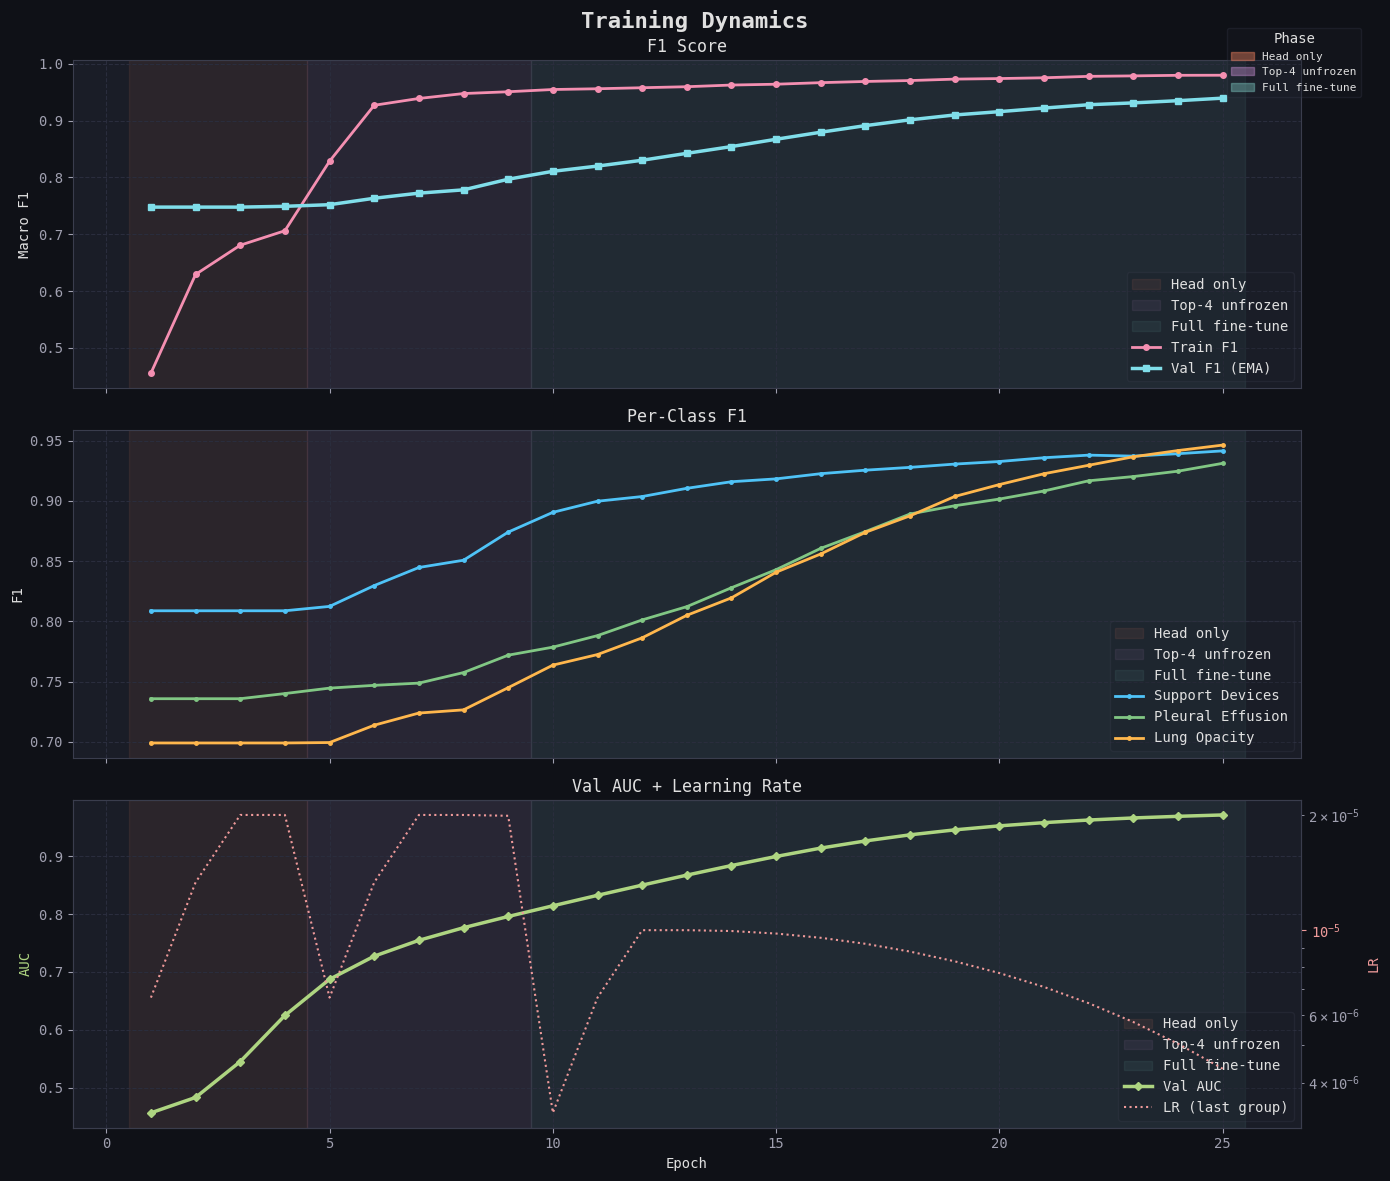

In [ ]:
def plot_training_curves(history):
    epochs = history['epoch']
    fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
    fig.suptitle('Training Dynamics', fontsize=16, fontweight='bold', y=0.98)

    phase_spans = [
        (1,                       CFG.unfreeze_top4_ep,   'Head only',     PHASE_COLORS['warm']),
        (CFG.unfreeze_top4_ep+1, CFG.unfreeze_all_ep,    'Top-4 unfrozen', PHASE_COLORS['top4']),
        (CFG.unfreeze_all_ep+1,  CFG.epochs,             'Full fine-tune', PHASE_COLORS['full']),
    ]

    for ax in axes:
        for start, end, label, col in phase_spans:
            ax.axvspan(start - 0.5, end + 0.5, alpha=0.08, color=col, label=label)
        ax.grid(True)

    # F1 curves
    axes[0].plot(epochs, history['train_f1'], color='#f48fb1', lw=2,
                 marker='o', ms=4, label='Train F1')
    axes[0].plot(epochs, history['val_f1'],   color='#80deea', lw=2.5,
                 marker='s', ms=4, label='Val F1 (EMA)')
    axes[0].set_ylabel('Macro F1')
    axes[0].set_title('F1 Score')
    axes[0].legend(loc='lower right')

    # Per-class F1
    for i, col in enumerate(CFG.label_cols):
        axes[1].plot(epochs, history['per_class_f1'][col],
                     color=CLASS_COLORS[i], lw=2, marker='.', ms=5, label=col)
    axes[1].set_ylabel('F1')
    axes[1].set_title('Per-Class F1')
    axes[1].legend(loc='lower right')

    # AUC + LR (twin axis)
    ax_auc = axes[2]
    ax_lr  = ax_auc.twinx()
    ax_auc.plot(epochs, history['val_auc'], color='#aed581', lw=2.5,
                marker='D', ms=4, label='Val AUC')
    ax_lr.plot(epochs, history['lr'], color='#ef9a9a', lw=1.5,
               ls=':', label='LR (last group)')
    ax_auc.set_ylabel('AUC',       color='#aed581')
    ax_lr.set_ylabel('LR',         color='#ef9a9a')
    ax_lr.tick_params(colors='#ef9a9a')
    ax_lr.set_yscale('log')
    ax_auc.set_title('Val AUC + Learning Rate')
    lines1, l1 = ax_auc.get_legend_handles_labels()
    lines2, l2 = ax_lr.get_legend_handles_labels()
    ax_auc.legend(lines1 + lines2, l1 + l2, loc='lower right')

    axes[2].set_xlabel('Epoch')

    # Phase legend (shared)
    patches = [mpatches.Patch(color=c, alpha=0.4, label=l)
               for _, _, l, c in phase_spans]
    fig.legend(handles=patches, loc='upper right', bbox_to_anchor=(0.98, 0.97),
               title='Phase', fontsize=8)

    plt.tight_layout()
    plt.savefig('/content/01_training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_training_curves(history)

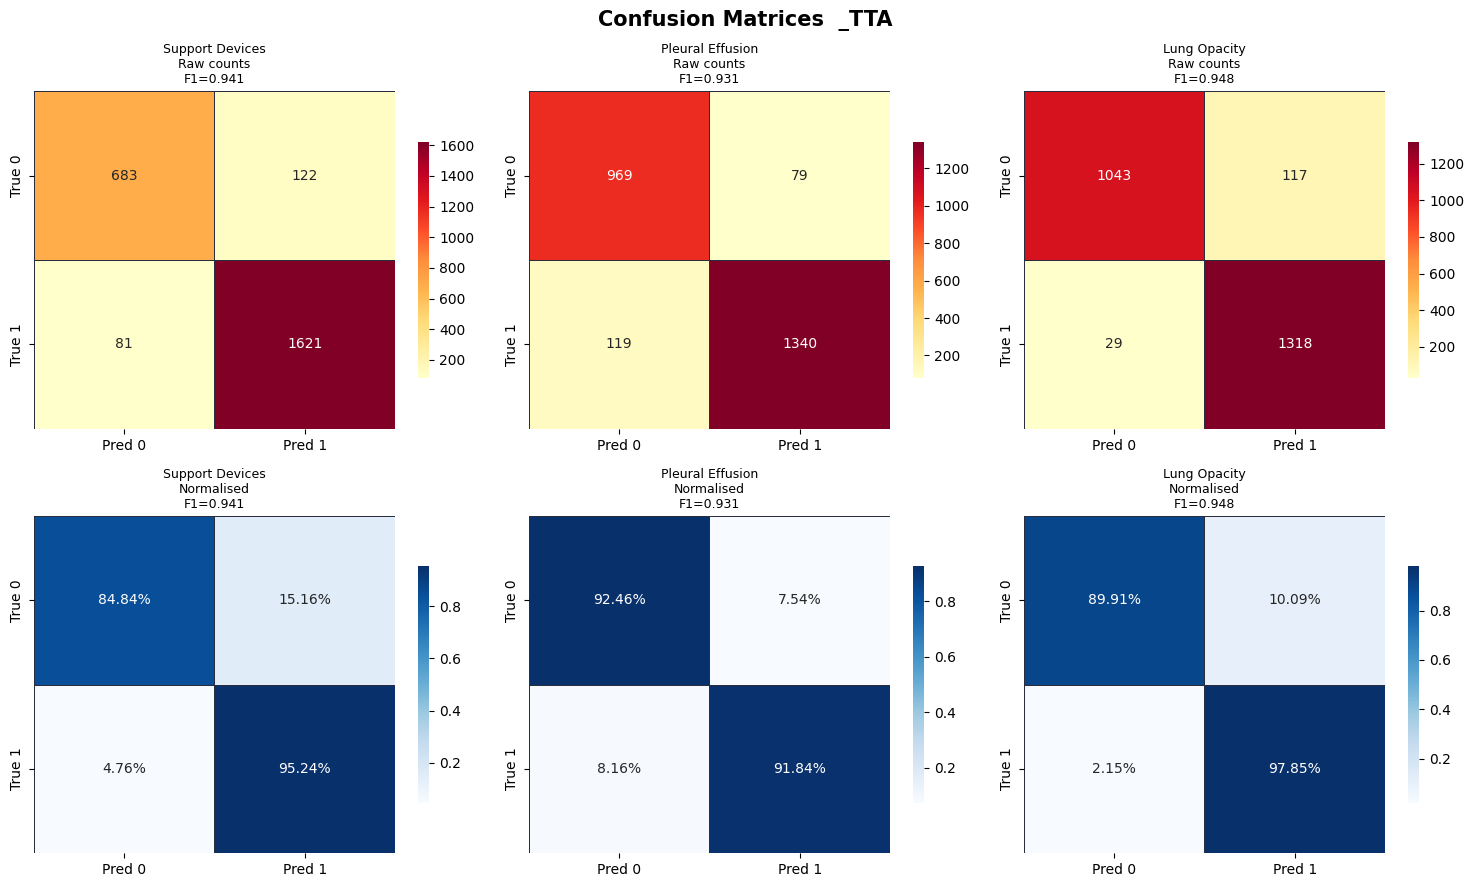

In [ ]:
def plot_confusion_matrices(labels, preds, probs, title_suffix=''):
    fig, axes = plt.subplots(2, CFG.num_classes,
                             figsize=(5 * CFG.num_classes, 9))
    fig.suptitle(f'Confusion Matrices  {title_suffix}',
                 fontsize=15, fontweight='bold')

    for i, col in enumerate(CFG.label_cols):
        for row, norm in enumerate([None, 'true']):
            cm   = confusion_matrix(labels[:, i], preds[:, i], normalize=norm)
            fmt  = '.2%' if norm else 'd'
            cmap = 'Blues' if norm else 'YlOrRd'
            sns.heatmap(cm, annot=True, fmt=fmt, cmap=cmap,
                        ax=axes[row, i],
                        xticklabels=['Pred 0', 'Pred 1'],
                        yticklabels=['True 0', 'True 1'],
                        linewidths=0.5, linecolor='#2a2d3d',
                        cbar_kws={'shrink': 0.7})
            sub = 'Normalised' if norm else 'Raw counts'
            axes[row, i].set_title(
                f"{col}\n{sub}\nF1={f1_score(labels[:,i],preds[:,i],zero_division=0):.3f}",
                fontsize=9)

    plt.tight_layout()
    plt.savefig(f'/content/02_confusion_matrices{title_suffix}.png',
                dpi=150, bbox_inches='tight')
    plt.show()

# Using best TTA predictions & labels
plot_confusion_matrices(v_labels, final_preds, tta_probs, title_suffix='_TTA')

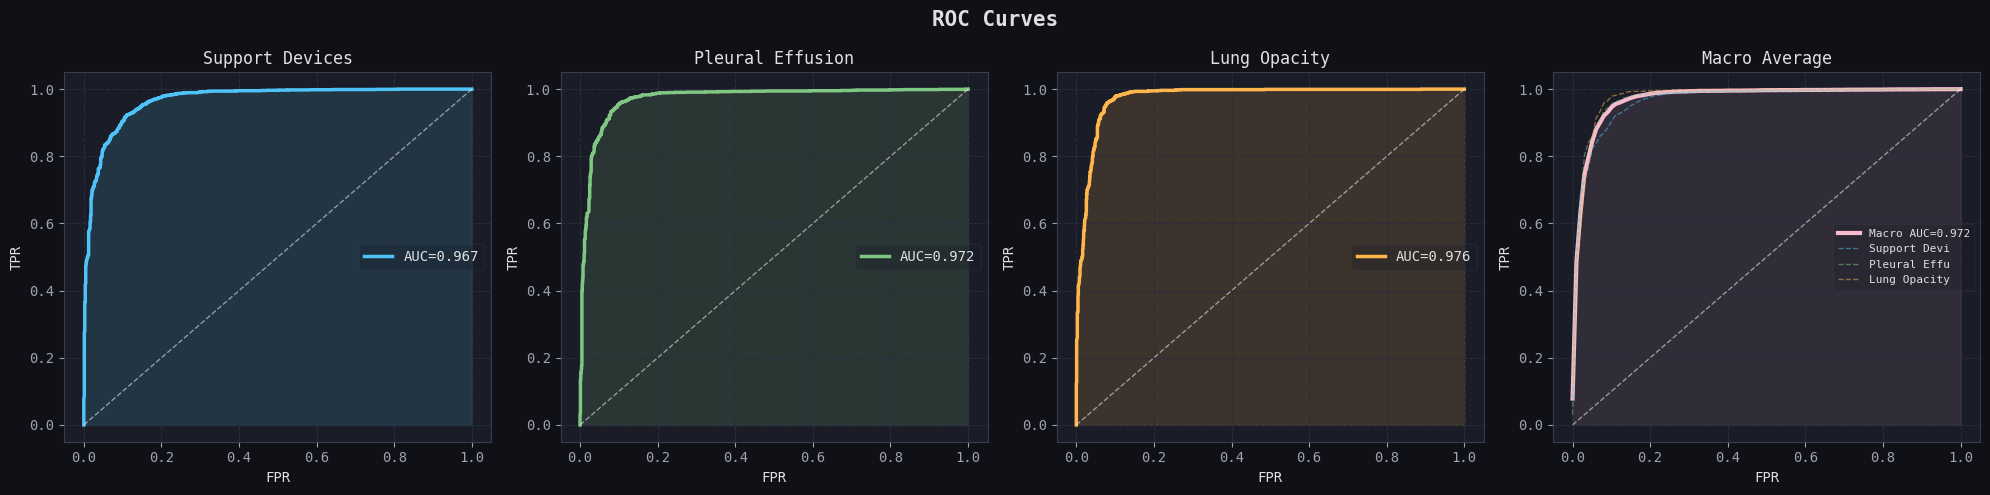

In [ ]:
def plot_roc_curves(labels, probs):
    fig, axes = plt.subplots(1, CFG.num_classes + 1,
                             figsize=(5 * (CFG.num_classes + 1), 5))
    fig.suptitle('ROC Curves', fontsize=15, fontweight='bold')

    all_fpr = np.linspace(0, 1, 100)
    tprs    = []

    for i, col in enumerate(CFG.label_cols):
        fpr, tpr, _ = roc_curve(labels[:, i], probs[:, i])
        auc_i       = roc_auc_score(labels[:, i], probs[:, i])
        tprs.append(np.interp(all_fpr, fpr, tpr))

        axes[i].plot(fpr, tpr, color=CLASS_COLORS[i], lw=2.5,
                     label=f'AUC={auc_i:.3f}')
        axes[i].fill_between(fpr, tpr, alpha=0.15, color=CLASS_COLORS[i])
        axes[i].plot([0, 1], [0, 1], 'w--', lw=1, alpha=0.5)
        axes[i].set_xlabel('FPR'); axes[i].set_ylabel('TPR')
        axes[i].set_title(col); axes[i].legend()
        axes[i].grid(True)

    # Macro-average ROC
    mean_tpr = np.mean(tprs, axis=0)
    mean_auc = roc_auc_score(labels, probs, average='macro')
    axes[-1].plot(all_fpr, mean_tpr, color='#f8bbd0', lw=3,
                  label=f'Macro AUC={mean_auc:.3f}')
    for i, (col, tpr_i) in enumerate(zip(CFG.label_cols, tprs)):
        axes[-1].plot(all_fpr, tpr_i, color=CLASS_COLORS[i], lw=1,
                      alpha=0.5, ls='--', label=col[:12])
    axes[-1].fill_between(all_fpr, mean_tpr, alpha=0.1, color='#f8bbd0')
    axes[-1].plot([0, 1], [0, 1], 'w--', lw=1, alpha=0.5)
    axes[-1].set_xlabel('FPR'); axes[-1].set_ylabel('TPR')
    axes[-1].set_title('Macro Average')
    axes[-1].legend(fontsize=8); axes[-1].grid(True)

    plt.tight_layout()
    plt.savefig('/content/03_roc_curves.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_roc_curves(v_labels, tta_probs)

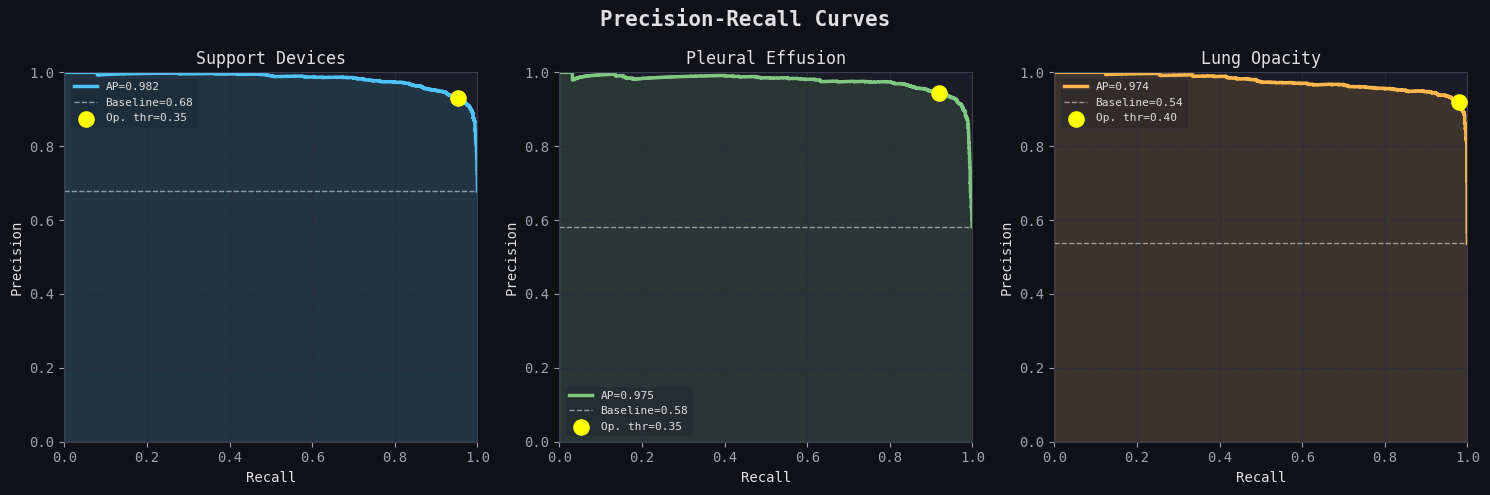

In [ ]:
def plot_pr_curves(labels, probs):
    fig, axes = plt.subplots(1, CFG.num_classes,
                             figsize=(5 * CFG.num_classes, 5))
    fig.suptitle('Precision-Recall Curves', fontsize=15, fontweight='bold')

    for i, col in enumerate(CFG.label_cols):
        prec, rec, thr = precision_recall_curve(labels[:, i], probs[:, i])
        ap_i            = average_precision_score(labels[:, i], probs[:, i])
        baseline        = labels[:, i].mean()

        axes[i].step(rec, prec, color=CLASS_COLORS[i], lw=2.5, where='post',
                     label=f'AP={ap_i:.3f}')
        axes[i].fill_between(rec, prec, step='post', alpha=0.15,
                             color=CLASS_COLORS[i])
        axes[i].axhline(baseline, color='white', lw=1, ls='--', alpha=0.5,
                        label=f'Baseline={baseline:.2f}')

        # Mark operating threshold point
        op_thr = final_thr[i]
        closest = np.argmin(np.abs(thr - op_thr)) if len(thr) > 0 else 0
        axes[i].scatter(rec[closest], prec[closest], s=120, zorder=5,
                        color='yellow', label=f'Op. thr={op_thr:.2f}')

        axes[i].set_xlabel('Recall'); axes[i].set_ylabel('Precision')
        axes[i].set_title(col); axes[i].legend(fontsize=8)
        axes[i].grid(True); axes[i].set_xlim([0, 1]); axes[i].set_ylim([0, 1])

    plt.tight_layout()
    plt.savefig('/content/04_pr_curves.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_pr_curves(v_labels, tta_probs)

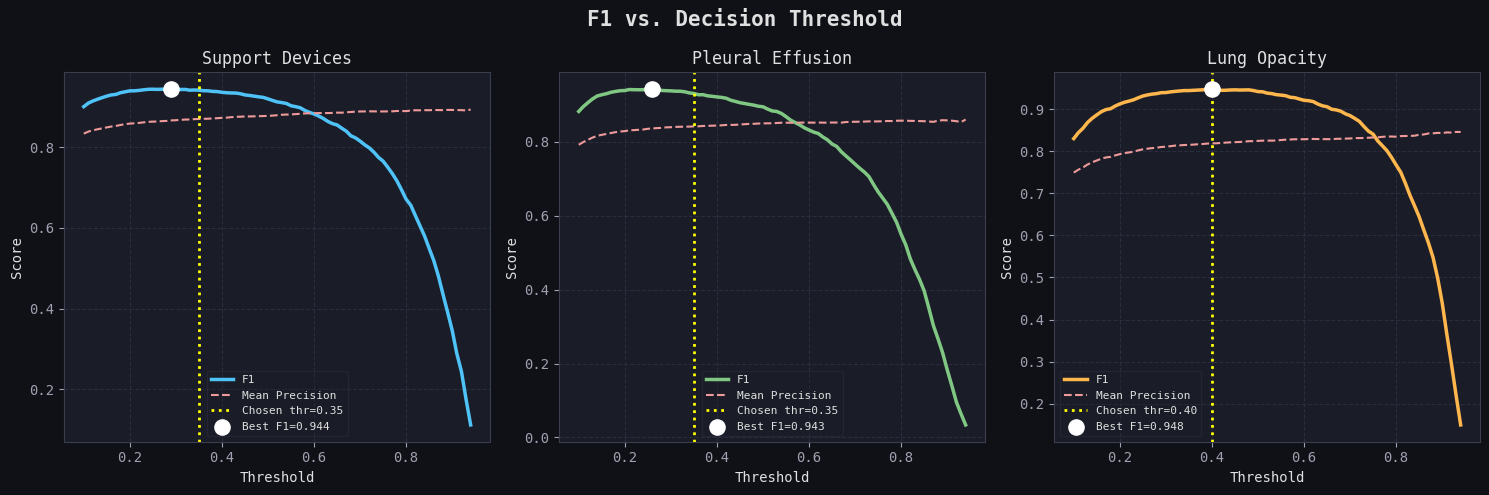

In [ ]:
def plot_threshold_sensitivity(labels, probs):
    fig, axes = plt.subplots(1, CFG.num_classes,
                             figsize=(5 * CFG.num_classes, 5))
    fig.suptitle('F1 vs. Decision Threshold', fontsize=15, fontweight='bold')

    thrs = np.arange(0.1, 0.95, 0.01)

    for i, col in enumerate(CFG.label_cols):
        f1s   = [f1_score(labels[:, i], (probs[:, i] > t).astype(int),
                          zero_division=0) for t in thrs]
        precs = [precision_recall_curve(labels[:, i],
                 (probs[:, i] > t).astype(int))[0].mean() for t in thrs]

        axes[i].plot(thrs, f1s,   color=CLASS_COLORS[i], lw=2.5, label='F1')
        axes[i].plot(thrs, precs, color='#ef9a9a', lw=1.5, ls='--',
                     label='Mean Precision')
        axes[i].axvline(final_thr[i], color='yellow', lw=2, ls=':',
                        label=f'Chosen thr={final_thr[i]:.2f}')
        best_idx = int(np.argmax(f1s))
        axes[i].scatter(thrs[best_idx], f1s[best_idx], s=120, color='white',
                        zorder=5, label=f'Best F1={f1s[best_idx]:.3f}')
        axes[i].set_xlabel('Threshold'); axes[i].set_ylabel('Score')
        axes[i].set_title(col); axes[i].legend(fontsize=8)
        axes[i].grid(True)

    plt.tight_layout()
    plt.savefig('/content/05_threshold_sensitivity.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_threshold_sensitivity(v_labels, tta_probs)

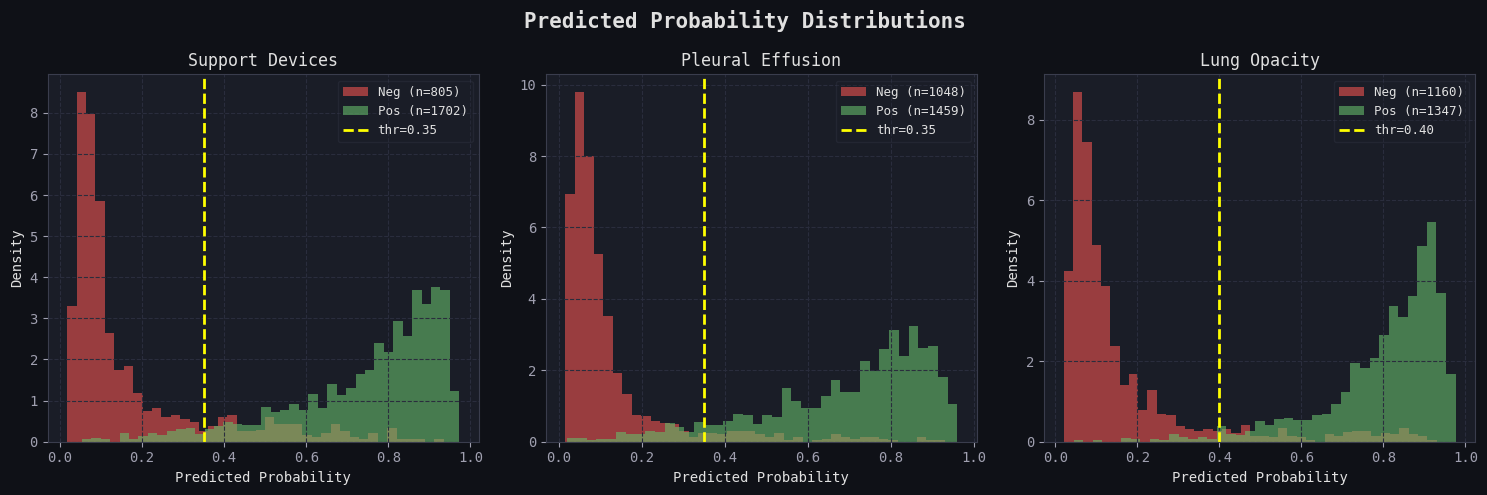

In [ ]:
def plot_prob_distributions(labels, probs):
    fig, axes = plt.subplots(1, CFG.num_classes,
                             figsize=(5 * CFG.num_classes, 5))
    fig.suptitle('Predicted Probability Distributions', fontsize=15,
                 fontweight='bold')

    for i, col in enumerate(CFG.label_cols):
        pos_mask = labels[:, i] == 1
        neg_mask = ~pos_mask

        axes[i].hist(probs[neg_mask, i], bins=40, color='#ef5350', alpha=0.6,
                     density=True, label=f'Neg (n={neg_mask.sum()})')
        axes[i].hist(probs[pos_mask, i], bins=40, color='#66bb6a', alpha=0.6,
                     density=True, label=f'Pos (n={pos_mask.sum()})')
        axes[i].axvline(final_thr[i], color='yellow', lw=2, ls='--',
                        label=f'thr={final_thr[i]:.2f}')
        axes[i].set_xlabel('Predicted Probability')
        axes[i].set_ylabel('Density')
        axes[i].set_title(col)
        axes[i].legend(fontsize=9)
        axes[i].grid(True)

    plt.tight_layout()
    plt.savefig('/content/06_prob_distributions.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_prob_distributions(v_labels, tta_probs)

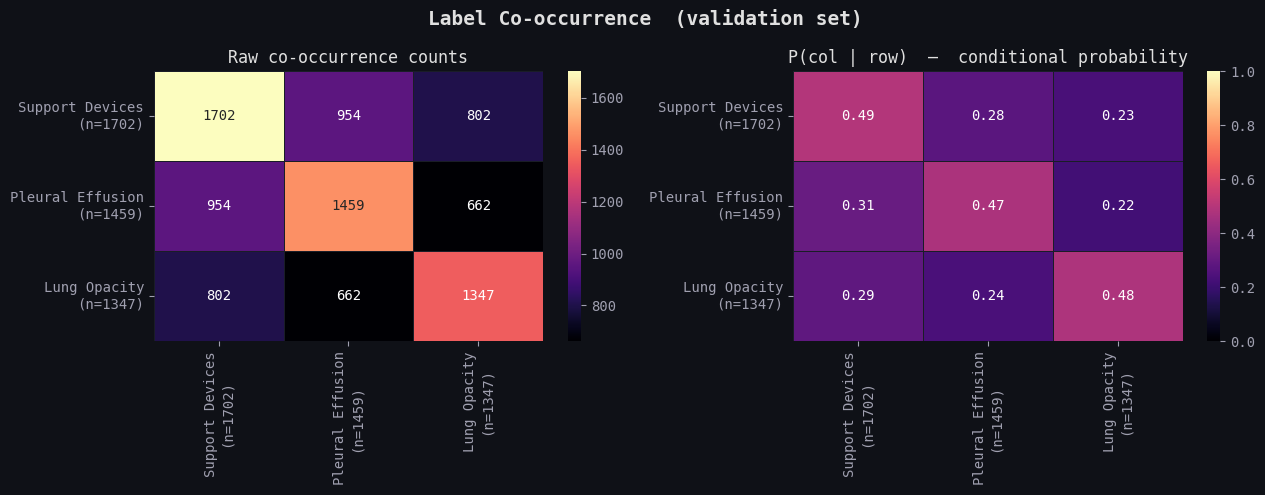

In [ ]:
def plot_label_cooccurrence(labels):
    comat  = (labels.T @ labels).astype(int)
    counts = labels.sum(0).astype(int)
    label_disp = [f"{c}\n(n={counts[i]})" for i, c in enumerate(CFG.label_cols)]

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle('Label Co-occurrence  (validation set)', fontsize=14,
                 fontweight='bold')

    sns.heatmap(comat, annot=True, fmt='d', cmap='magma',
                xticklabels=label_disp, yticklabels=label_disp,
                ax=axes[0], linewidths=0.5, linecolor='#1a1d27')
    axes[0].set_title('Raw co-occurrence counts')

    # Normalised by row (P(B|A))
    row_sum = comat.sum(1, keepdims=True).astype(float)
    norm_co = np.where(row_sum > 0, comat / row_sum, 0)
    sns.heatmap(norm_co, annot=True, fmt='.2f', cmap='magma',
                xticklabels=label_disp, yticklabels=label_disp,
                ax=axes[1], linewidths=0.5, linecolor='#1a1d27',
                vmin=0, vmax=1)
    axes[1].set_title('P(col | row)  —  conditional probability')

    plt.tight_layout()
    plt.savefig('/content/07_label_cooccurrence.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_label_cooccurrence(v_labels)

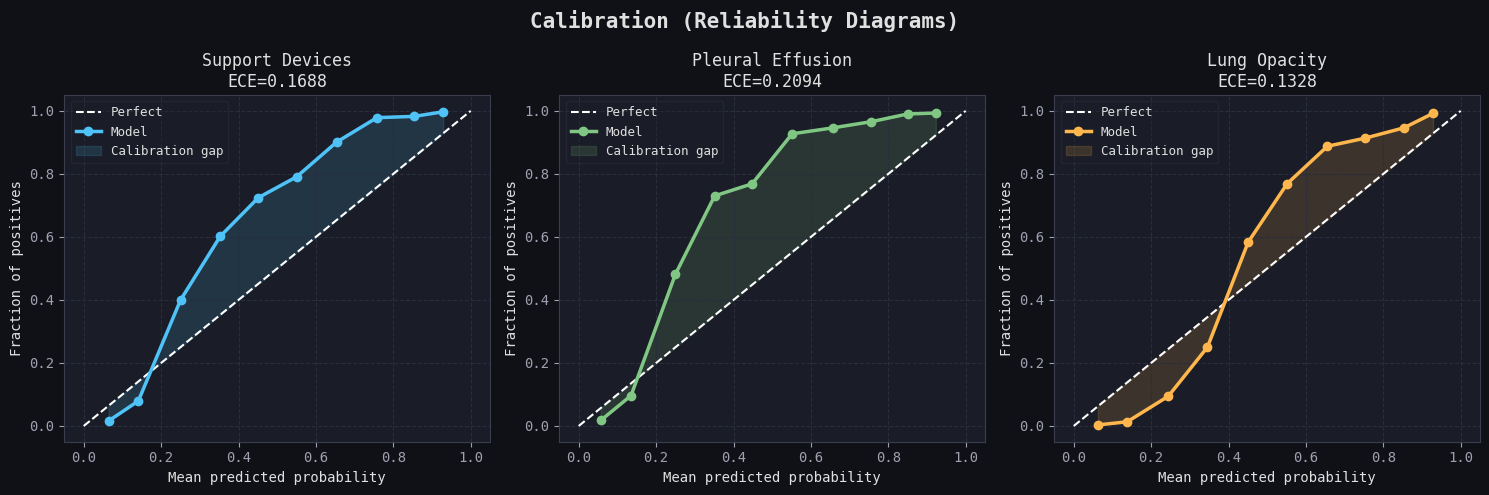

In [ ]:
def plot_calibration(labels, probs):
    fig, axes = plt.subplots(1, CFG.num_classes,
                             figsize=(5 * CFG.num_classes, 5))
    fig.suptitle('Calibration (Reliability Diagrams)',
                 fontsize=15, fontweight='bold')

    for i, col in enumerate(CFG.label_cols):
        frac_pos, mean_pred = calibration_curve(
            labels[:, i], probs[:, i], n_bins=10, strategy='uniform')

        axes[i].plot([0, 1], [0, 1], 'w--', lw=1.5, label='Perfect')
        axes[i].plot(mean_pred, frac_pos, color=CLASS_COLORS[i],
                     lw=2.5, marker='o', ms=6, label='Model')
        axes[i].fill_between(mean_pred, frac_pos, mean_pred,
                             alpha=0.15, color=CLASS_COLORS[i],
                             label='Calibration gap')

        ece = np.mean(np.abs(frac_pos - mean_pred))
        axes[i].set_xlabel('Mean predicted probability')
        axes[i].set_ylabel('Fraction of positives')
        axes[i].set_title(f'{col}\nECE={ece:.4f}')
        axes[i].legend(fontsize=9); axes[i].grid(True)

    plt.tight_layout()
    plt.savefig('/content/08_calibration.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_calibration(v_labels, tta_probs)


── Grad-CAM Token Importance  (one example per class) ──

  Class: Support Devices  (example idx=2167 p=0.973)


/tmp/ipykernel_1669/3082638005.py:46: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('RdYlGn')


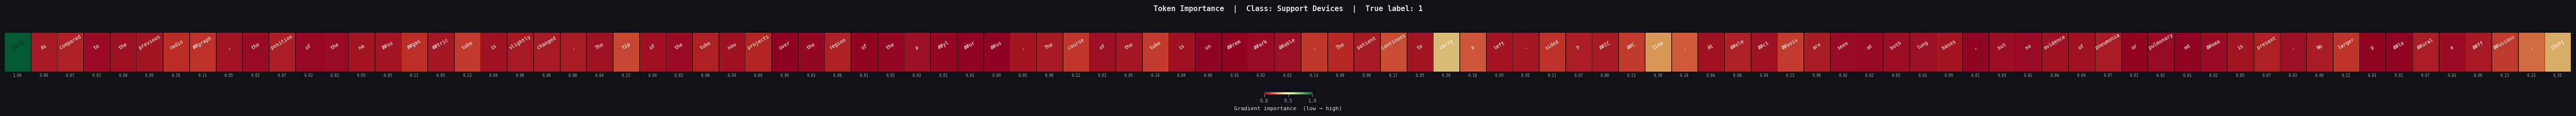

  Saved → /content/10_gradcam_class0.png

  Class: Pleural Effusion  (example idx=1396 p=0.960)


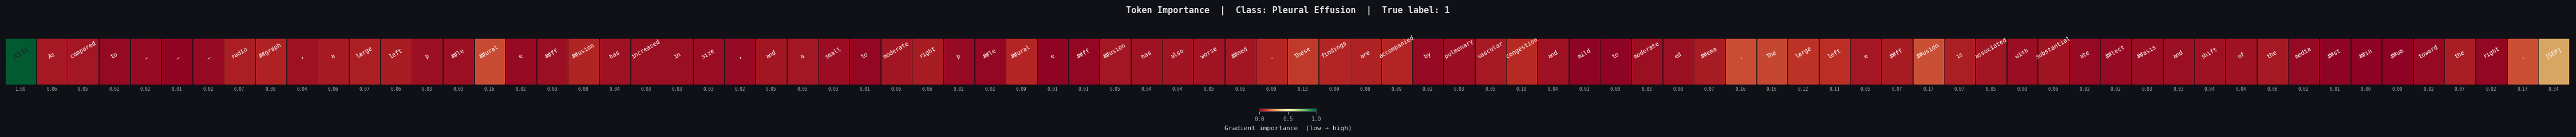

  Saved → /content/10_gradcam_class1.png

  Class: Lung Opacity  (example idx=1289 p=0.976)


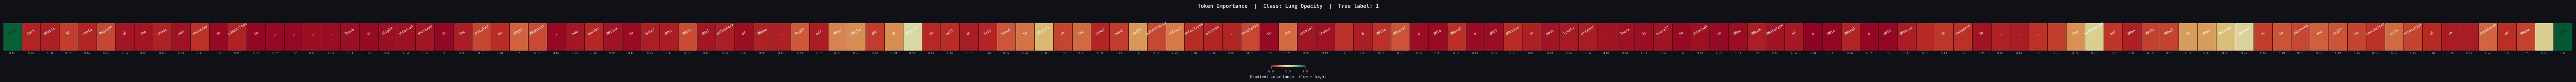

  Saved → /content/10_gradcam_class2.png


In [ ]:
def token_gradcam(model, tokenizer, text, target_class_idx, device,
                 max_len=CFG.max_len):
    enc = tokenizer(text, max_length=max_len, padding='max_length',
                    truncation=True, return_tensors='pt')
    input_ids      = enc['input_ids'].to(device)
    attention_mask = enc['attention_mask'].to(device)

    model.eval()
    emb = model.bert.embeddings(input_ids)
    emb.retain_grad()

    out    = model.bert.encoder(emb, attention_mask=attention_mask
                                     .unsqueeze(1).unsqueeze(2)
                                     .to(emb.dtype))
    cls    = out.last_hidden_state[:, 0, :]
    logit  = model.head(cls)[0, target_class_idx]

    logit.backward()

    grad        = emb.grad[0].detach().cpu().numpy()
    importance  = np.linalg.norm(grad, axis=-1)

    real_len    = int(attention_mask.sum().item())
    tokens_ids  = input_ids[0, :real_len].cpu().numpy()
    tokens      = tokenizer.convert_ids_to_tokens(tokens_ids)
    importance  = importance[:real_len]

    return tokens, importance

def plot_token_importance(text, target_class_idx, model, tokenizer, device,
                         sample_label=None):
    tokens, imp = token_gradcam(model, tokenizer, text,
                                target_class_idx, device)
    imp_norm = (imp - imp.min()) / (imp.max() - imp.min() + 1e-9)

    col_name  = CFG.label_cols[target_class_idx]
    n_tokens  = len(tokens)
    fig_w     = max(14, n_tokens * 0.55)
    fig, ax   = plt.subplots(figsize=(fig_w, 2.5))
    ax.set_xlim(0, n_tokens)
    ax.set_ylim(0, 1)
    ax.axis('off')
    ax.set_facecolor('#0f1117')
    fig.patch.set_facecolor('#0f1117')

    cmap = plt.cm.get_cmap('RdYlGn')

    for j, (tok, score) in enumerate(zip(tokens, imp_norm)):
        color = cmap(score)
        ax.add_patch(plt.Rectangle((j, 0.25), 0.95, 0.5,
                                   color=color, alpha=0.85))
        ax.text(j + 0.47, 0.52, tok, ha='center', va='bottom',
                fontsize=7.5, color='white' if score < 0.7 else '#1a1a1a',
                rotation=30, clip_on=True)
        ax.text(j + 0.47, 0.22, f'{score:.2f}', ha='center', va='top',
                fontsize=5.5, color='#aaaaaa')

    title = f"Token Importance  |  Class: {col_name}"
    if sample_label is not None:
        title += f"  |  True label: {int(sample_label)}"
    ax.set_title(title, fontsize=11, fontweight='bold', pad=4)

    sm = plt.cm.ScalarMappable(cmap=cmap)
    sm.set_array([0, 1])
    cbar = plt.colorbar(sm, ax=ax, orientation='horizontal',
                        fraction=0.03, pad=0.02)
    cbar.set_label('Gradient importance  (low → high)', fontsize=8)
    cbar.ax.tick_params(labelsize=7)

    plt.tight_layout()
    fname = f"/content/10_gradcam_class{target_class_idx}.png"
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  Saved → {fname}")

print("\n── Grad-CAM Token Importance  (one example per class) ──")
ema.shadow.load_state_dict(best_wts)
for p in ema.shadow.parameters(): p.requires_grad_(True)

for cls_idx, col in enumerate(CFG.label_cols):
    tp_indices = np.where((v_labels[:, cls_idx] == 1) &
                          (final_preds[:, cls_idx] == 1))[0]
    if len(tp_indices) == 0: tp_indices = np.where(v_labels[:, cls_idx] == 1)[0]
    if len(tp_indices) == 0: continue

    best_idx  = tp_indices[np.argmax(tta_probs[tp_indices, cls_idx])]
    text_ex   = str(val_df.loc[best_idx, 'text'])
    true_lbl  = v_labels[best_idx, cls_idx]
    print(f"\n  Class: {col}  (example idx={best_idx} p={tta_probs[best_idx, cls_idx]:.3f})")
    plot_token_importance(text_ex, cls_idx, ema.shadow, tokenizer, device, sample_label=true_lbl)

for p in ema.shadow.parameters(): p.requires_grad_(False)

In [ ]:
print("\n" + "="*60)
print("  CLASSIFICATION REPORT  (TTA predictions)")
print("="*60)
for i, col in enumerate(CFG.label_cols):
    print(f"\n── {col} ──")
    print(classification_report(
        v_labels[:, i], final_preds[:, i],
        target_names=['Absent', 'Present'], zero_division=0))

print("\nAll analysis plots saved to /content/*.png")


  CLASSIFICATION REPORT  (TTA predictions)

── Support Devices ──
              precision    recall  f1-score   support

      Absent       0.89      0.85      0.87       805
     Present       0.93      0.95      0.94      1702

    accuracy                           0.92      2507
   macro avg       0.91      0.90      0.91      2507
weighted avg       0.92      0.92      0.92      2507


── Pleural Effusion ──
              precision    recall  f1-score   support

      Absent       0.89      0.92      0.91      1048
     Present       0.94      0.92      0.93      1459

    accuracy                           0.92      2507
   macro avg       0.92      0.92      0.92      2507
weighted avg       0.92      0.92      0.92      2507


── Lung Opacity ──
              precision    recall  f1-score   support

      Absent       0.97      0.90      0.93      1160
     Present       0.92      0.98      0.95      1347

    accuracy                           0.94      2507
   macro avg     